In [ ]:
import gurobipy as gp
from gurobipy import GRB

m = gp.Model("test")
x = m.addVar(name="x")
m.setObjective(x, GRB.MAXIMIZE)
m.optimize()

print("Done")

Set parameter Username
Set parameter LicenseID to value 2810610
Academic license - for non-commercial use only - expires 2027-04-20
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 3750H with Radeon Vega Mobile Gfx, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 0 rows, 1 columns and 0 nonzeros (Max)
Model fingerprint: 0xb569a9c0
Model has 1 linear objective coefficients
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [0e+00, 0e+00]

Presolve time: 0.00s

Solved in 0 iterations and 0.00 seconds (0.00 work units)
Unbounded model
Done


In [6]:
# ==========================================
# OSM Road Network Extraction (FULL + LOCAL)
# ==========================================

import osmnx as ox
import pandas as pd

# -------------------------------
# 1. Settings
# -------------------------------
ox.settings.use_cache = True
ox.settings.log_console = True

# -------------------------------
# 2. Function to extract graph
# -------------------------------
def extract_graph(place_name=None, center_point=None, dist=1500, file_prefix="output"):
    
    print(f"\n===== Processing: {file_prefix} =====")

    # ---------------------------
    # Download graph
    # ---------------------------
    try:
        if place_name:
            print(f"Downloading using place: {place_name}")
            G = ox.graph_from_place(place_name, network_type="drive")
        else:
            raise Exception("Using fallback")
    except:
        print("Falling back to coordinates...")
        G = ox.graph_from_point(center_point, dist=dist, network_type="drive")

    print(f"Nodes: {len(G.nodes)}")
    print(f"Edges: {len(G.edges)}")

    # ---------------------------
    # Add weights
    # ---------------------------
    G = ox.add_edge_speeds(G)
    G = ox.add_edge_travel_times(G)

    # ---------------------------
    # Convert to GeoDataFrames
    # ---------------------------
    nodes, edges = ox.graph_to_gdfs(G)

    # ---------------------------
    # FIX: reset index
    # ---------------------------
    nodes = nodes.reset_index()
    edges = edges.reset_index()

    # ---------------------------
    # Nodes dataframe
    # ---------------------------
    nodes_df = nodes[['osmid', 'x', 'y']].copy()
    nodes_df.rename(columns={
        'osmid': 'node_id',
        'x': 'longitude',
        'y': 'latitude'
    }, inplace=True)

    # ---------------------------
    # Edges dataframe
    # ---------------------------
    if 'travel_time' in edges.columns:
        edges_df = edges[['u', 'v', 'length', 'travel_time']].copy()
    else:
        edges_df = edges[['u', 'v', 'length']].copy()
        edges_df['travel_time'] = None

    edges_df.rename(columns={
        'u': 'source',
        'v': 'target',
        'length': 'distance_meters',
        'travel_time': 'travel_time_seconds'
    }, inplace=True)

    # ---------------------------
    # Save CSV
    # ---------------------------
    nodes_file = f"{file_prefix}_nodes.csv"
    edges_file = f"{file_prefix}_edges.csv"

    nodes_df.to_csv(nodes_file, index=False)
    edges_df.to_csv(edges_file, index=False)

    print(f"Saved: {nodes_file}")
    print(f"Saved: {edges_file}")

    # ---------------------------
    # Save GraphML
    # ---------------------------
    graph_file = f"{file_prefix}.graphml"
    ox.save_graphml(G, graph_file)

    print(f"Saved: {graph_file}")

    return nodes_df, edges_df


# ==========================================
# 3. FULL BANGALORE
# ==========================================
bangalore_nodes, bangalore_edges = extract_graph(
    place_name="Bangalore, India",
    file_prefix="bangalore"
)

# ==========================================
# 4. MALLESHWARAM ONLY
# ==========================================
malleshwaram_nodes, malleshwaram_edges = extract_graph(
    place_name="Malleshwaram, Bangalore, India",
    center_point=(13.0035, 77.5690),
    dist=1500,
    file_prefix="malleshwaram"
)

# ==========================================
# DONE
# ==========================================
print("\n✅ Extraction complete for BOTH datasets!")


===== Processing: bangalore =====
Nodes: 155000
Edges: 393229
Saved: bangalore_nodes.csv
Saved: bangalore_edges.csv
Saved: bangalore.graphml

===== Processing: malleshwaram =====
Falling back to coordinates...
Nodes: 2392
Edges: 6728
Saved: malleshwaram_nodes.csv
Saved: malleshwaram_edges.csv
Saved: malleshwaram.graphml

✅ Extraction complete for BOTH datasets!


In [3]:
# widht
# ==========================================
# OSM Road Network Extraction (WITH WIDTH)
# ==========================================

import osmnx as ox
import pandas as pd
import numpy as np

# -------------------------------
# 1. Settings
# -------------------------------
ox.settings.use_cache = True
ox.settings.log_console = True

# -------------------------------
# 2. Helper: safe conversion
# -------------------------------
def safe_float(x):
    if isinstance(x, list):
        x = x[0]
    try:
        return float(x)
    except:
        return np.nan

# -------------------------------
# 3. Function to extract graph
# -------------------------------
def extract_graph(place_name=None, center_point=None, dist=1500, file_prefix="output"):
    
    print(f"\n===== Processing: {file_prefix} =====")

    # ---------------------------
    # Download graph
    # ---------------------------
    try:
        if place_name:
            print(f"Downloading using place: {place_name}")
            G = ox.graph_from_place(place_name, network_type="drive")
        else:
            raise Exception("Fallback to coordinates")
    except:
        print("Falling back to coordinates...")
        G = ox.graph_from_point(center_point, dist=dist, network_type="drive")

    print(f"Nodes: {len(G.nodes)}")
    print(f"Edges: {len(G.edges)}")

    # ---------------------------
    # Add speeds & travel time
    # ---------------------------
    G = ox.add_edge_speeds(G)
    G = ox.add_edge_travel_times(G)

    # ---------------------------
    # Convert to GeoDataFrames
    # ---------------------------
    nodes, edges = ox.graph_to_gdfs(G)

    nodes = nodes.reset_index()
    edges = edges.reset_index()

    # ---------------------------
    # Nodes dataframe
    # ---------------------------
    nodes_df = nodes[['osmid', 'x', 'y']].copy()
    nodes_df.rename(columns={
        'osmid': 'node_id',
        'x': 'longitude',
        'y': 'latitude'
    }, inplace=True)

    # ---------------------------
    # Extract useful columns safely
    # ---------------------------
    edges['lanes'] = edges['lanes'].apply(safe_float) if 'lanes' in edges else np.nan
    edges['width'] = edges['width'].apply(safe_float) if 'width' in edges else np.nan
    edges['maxspeed'] = edges['maxspeed'].apply(safe_float) if 'maxspeed' in edges else np.nan

    # ---------------------------
    # Core columns
    # ---------------------------
    cols = ['u', 'v', 'length', 'travel_time', 'lanes', 'width', 'maxspeed', 'highway']
    existing_cols = [c for c in cols if c in edges.columns]

    edges_df = edges[existing_cols].copy()

    # ---------------------------
    # Rename columns
    # ---------------------------
    edges_df.rename(columns={
        'u': 'source',
        'v': 'target',
        'length': 'distance_meters',
        'travel_time': 'travel_time_seconds',
        'lanes': 'num_lanes',
        'width': 'road_width_meters',
        'maxspeed': 'maxspeed_kmph'
    }, inplace=True)

    # ---------------------------
    # Estimate width if missing
    # ---------------------------
    # 1 lane ≈ 3.5 meters
    edges_df['estimated_width_meters'] = edges_df['num_lanes'] * 3.5

    # Fill missing width using estimate
    edges_df['final_width_meters'] = edges_df['road_width_meters']
    edges_df['final_width_meters'] = edges_df['final_width_meters'].fillna(
        edges_df['estimated_width_meters']
    )

    # ---------------------------
    # Capacity score (VERY USEFUL)
    # ---------------------------
    edges_df['capacity_score'] = (
        edges_df['num_lanes'].fillna(1) *
        edges_df['maxspeed_kmph'].fillna(30)
    )

    # ---------------------------
    # Save CSV
    # ---------------------------
    nodes_file = f"{file_prefix}_nodes.csv"
    edges_file = f"{file_prefix}_edges.csv"

    nodes_df.to_csv(nodes_file, index=False)
    edges_df.to_csv(edges_file, index=False)

    print(f"Saved: {nodes_file}")
    print(f"Saved: {edges_file}")

    # ---------------------------
    # Save GraphML
    # ---------------------------
    graph_file = f"{file_prefix}.graphml"
    ox.save_graphml(G, graph_file)

    print(f"Saved: {graph_file}")

    return nodes_df, edges_df


# ==========================================
# 4. FULL BANGALORE
# ==========================================
bangalore_nodes, bangalore_edges = extract_graph(
    place_name="Bangalore, India",
    file_prefix="bangalore"
)

# ==========================================
# 5. MALLESHWARAM ONLY
# ==========================================
malleshwaram_nodes, malleshwaram_edges = extract_graph(
    place_name="Malleshwaram, Bangalore, India",
    center_point=(13.0035, 77.5690),
    dist=1500,
    file_prefix="malleshwaram"
)

# ==========================================
# DONE
# ==========================================
print("\n✅ Extraction complete for BOTH datasets!")


===== Processing: bangalore =====
Nodes: 155000
Edges: 393229
Saved: bangalore_nodes.csv
Saved: bangalore_edges.csv
Saved: bangalore.graphml

===== Processing: malleshwaram =====
Falling back to coordinates...
Nodes: 2392
Edges: 6728
Saved: malleshwaram_nodes.csv
Saved: malleshwaram_edges.csv
Saved: malleshwaram.graphml

✅ Extraction complete for BOTH datasets!


In [5]:
df = pd.read_csv("malleshwaram_edges.csv")
print(len(df))
df.isnull().sum()   

6728


source                       0
target                       0
distance_meters              0
travel_time_seconds          0
num_lanes                 6096
road_width_meters         6697
maxspeed_kmph             6523
highway                      0
estimated_width_meters    6096
final_width_meters        6072
capacity_score               0
dtype: int64

MST Nodes: 2392
MST Edges: 2391


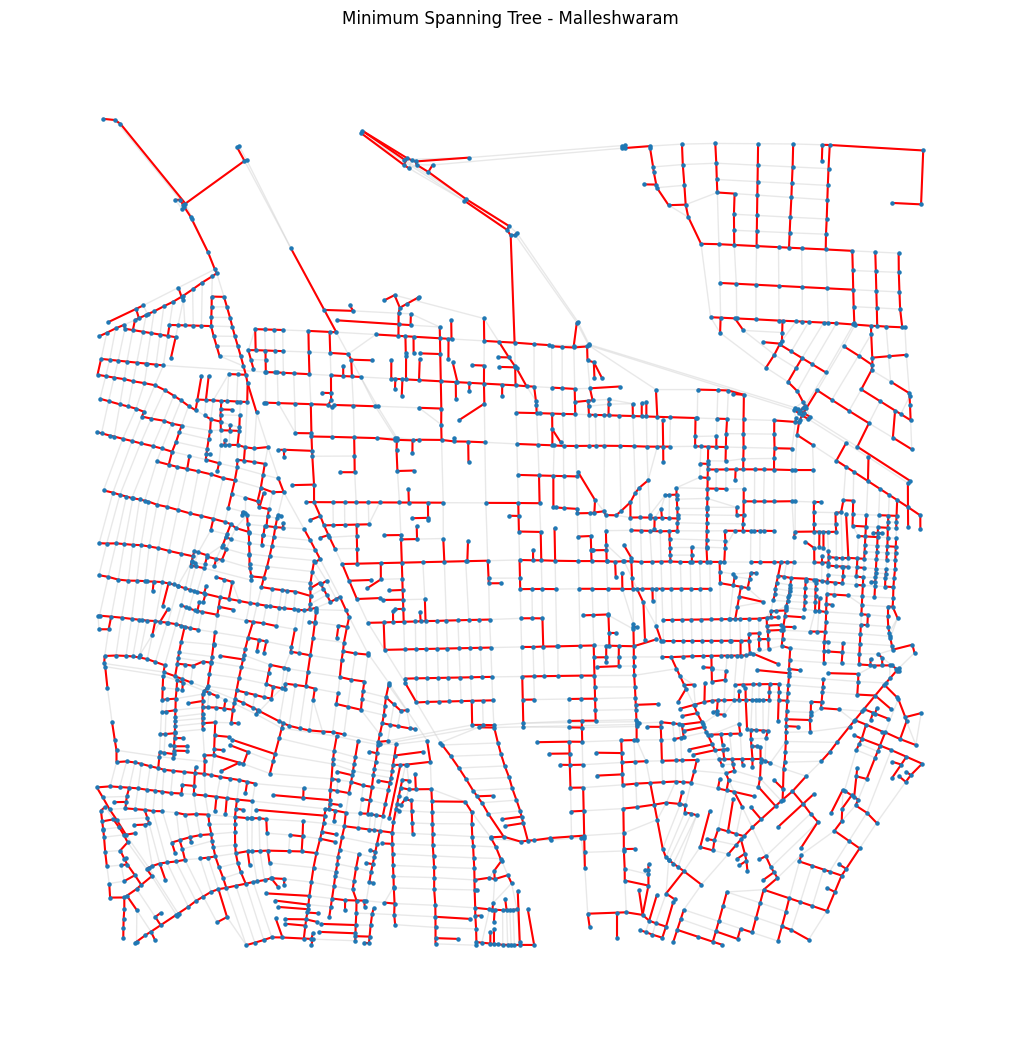

In [6]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load Malleshwaram graph
# -------------------------------
place = "Malleshwaram, Bangalore, India"

try:
    G = ox.graph_from_place(place, network_type="drive")
except:
    G = ox.graph_from_point((13.0035, 77.5690), dist=1500, network_type="drive")

# -------------------------------
# 2. Add weights
# -------------------------------
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

# -------------------------------
# 3. Convert to undirected (FIXED)
# -------------------------------
G_undirected = ox.convert.to_undirected(G)

# -------------------------------
# 4. Build simple weighted graph
# -------------------------------
G_simple = nx.Graph()

for u, v, data in G_undirected.edges(data=True):
    weight = data.get("length", 1)

    if G_simple.has_edge(u, v):
        if weight < G_simple[u][v]["weight"]:
            G_simple[u][v]["weight"] = weight
    else:
        G_simple.add_edge(u, v, weight=weight)

# -------------------------------
# 5. Compute MST
# -------------------------------
mst = nx.minimum_spanning_tree(G_simple, weight="weight")

print(f"MST Nodes: {len(mst.nodes)}")
print(f"MST Edges: {len(mst.edges)}")

# -------------------------------
# 6. Get positions
# -------------------------------
pos = {node: (data["x"], data["y"]) for node, data in G.nodes(data=True)}

# -------------------------------
# 7. Plot
# -------------------------------
plt.figure(figsize=(10, 10))

# Original graph (light)
nx.draw(G_simple, pos, node_size=1, edge_color="lightgray", alpha=0.5)

# MST (highlighted)
nx.draw(mst, pos, node_size=5, edge_color="red", width=1.5)

plt.title("Minimum Spanning Tree - Malleshwaram")
plt.show()

In [7]:
total_weight = sum(data["weight"] for u, v, data in mst.edges(data=True))

print(f"Total MST weight (meters): {total_weight:.2f}")
print(f"Total MST weight (km): {total_weight/1000:.2f}")

Total MST weight (meters): 93877.36
Total MST weight (km): 93.88


Loaded: 2392 nodes, 6728 edges
Graph created: 2392 nodes, 3581 edges
Running Greedy Heuristic...
Budget Used: ₹4,694,668 / ₹8,000,000
Connected Pairs: 2,859,636
Generating plot...


c:\Users\maddi\AppData\Local\Programs\Python\Python312\Lib\site-packages\networkx\drawing\nx_pylab.py:1438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


Plot saved as: malleshwaram_green_selected_B8.0M.png


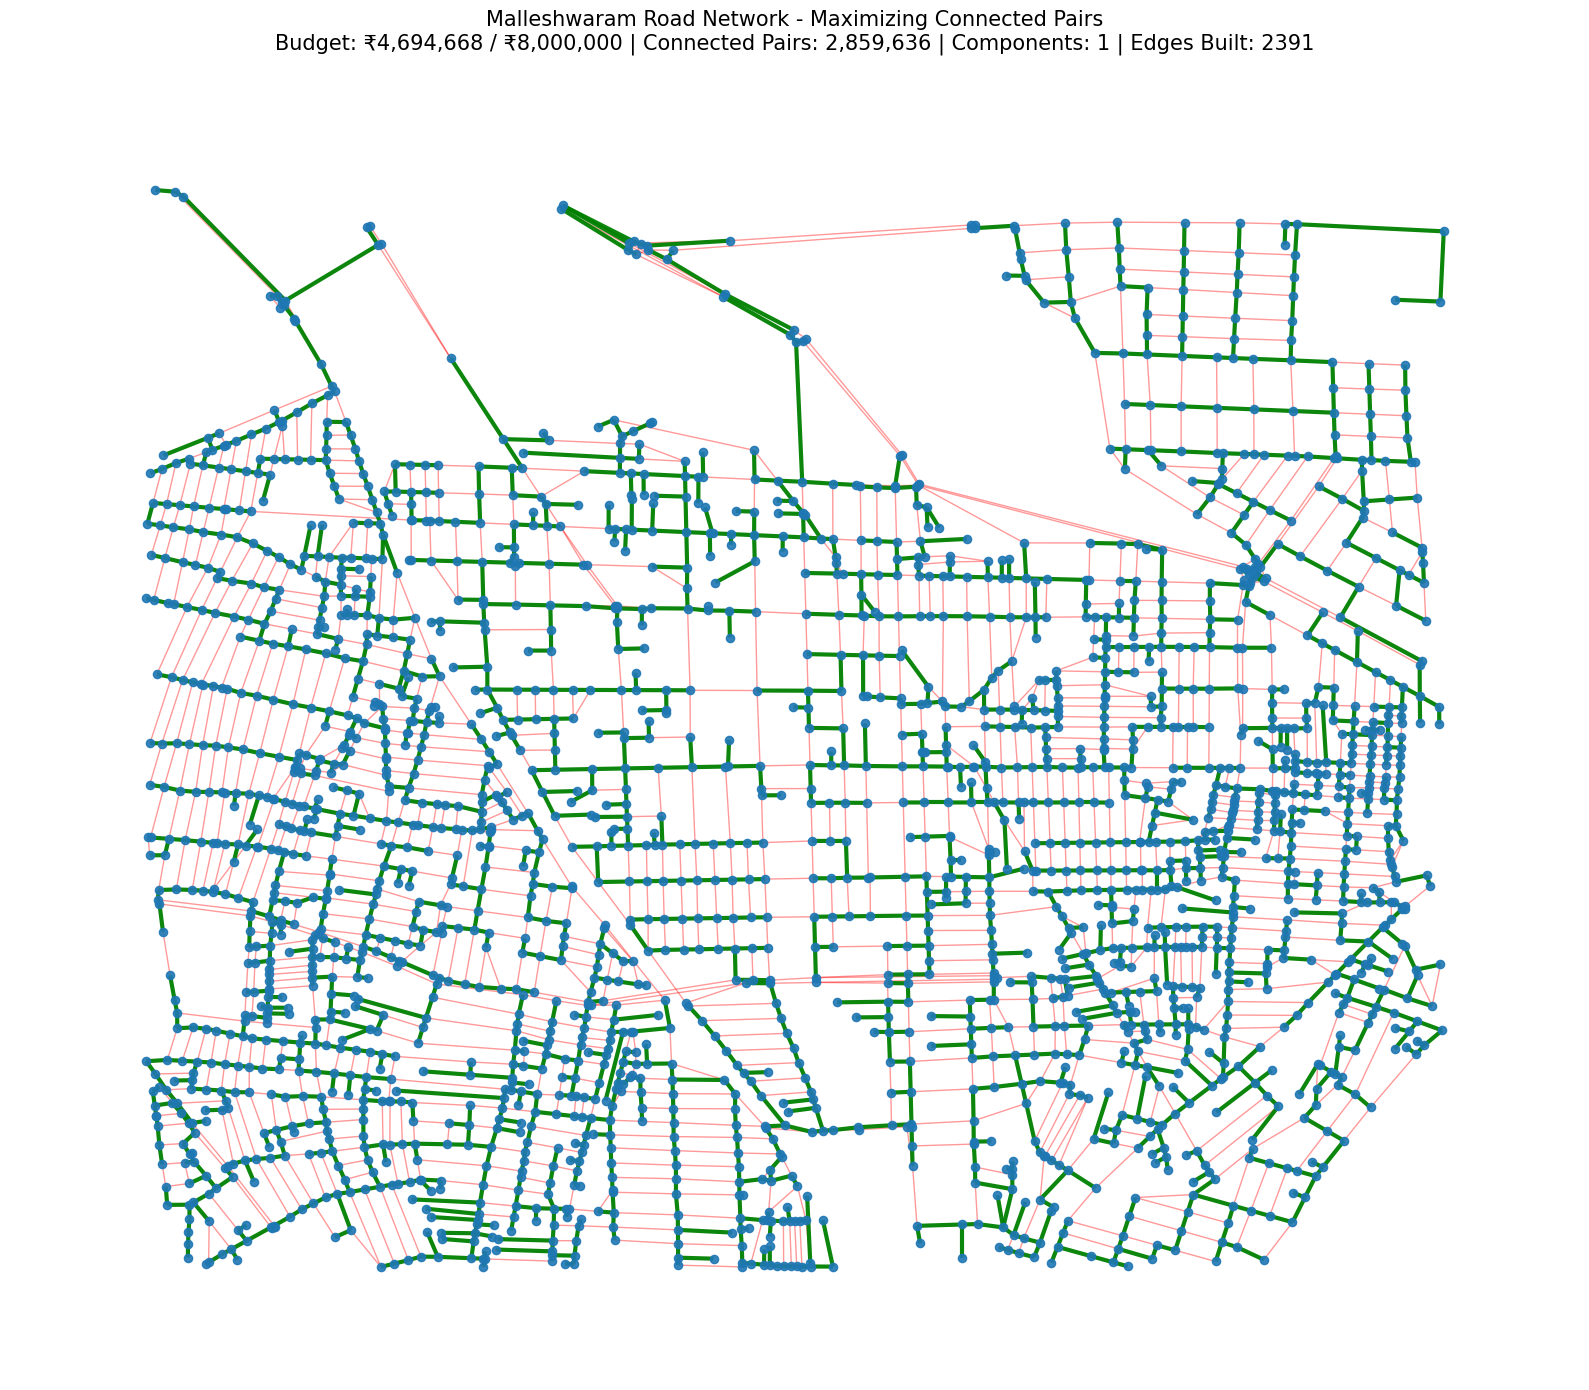

In [13]:
# =====================================================
# Budgeted Max Connected Pairs + Plotting (Green Selected)
# =====================================================

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load Data
# -------------------------------
nodes_df = pd.read_csv("malleshwaram_nodes.csv")
edges_df = pd.read_csv("malleshwaram_edges.csv")

print(f"Loaded: {len(nodes_df)} nodes, {len(edges_df)} edges")

# Create NetworkX Graph
G = nx.Graph()
for _, row in nodes_df.iterrows():
    G.add_node(int(row['node_id']), 
               x=row['longitude'], 
               y=row['latitude'])

for _, row in edges_df.iterrows():
    cost = float(row['distance_meters']) * 50   # ← Adjust this multiplier
    G.add_edge(int(row['source']), int(row['target']), 
               cost=cost, 
               length=row['distance_meters'])

print(f"Graph created: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# -------------------------------
# 2. Budget
# -------------------------------
B = 8_000_000   # ←←← Change this value and re-run to experiment

# -------------------------------
# 3. Greedy Heuristic
# -------------------------------
def greedy_max_pairs(G, budget):
    edges_sorted = sorted(G.edges(data=True), key=lambda e: e[2]['cost'])
    uf = nx.utils.UnionFind()
    size = {node: 1 for node in G.nodes()}
    total_pairs = 0
    selected = []
    spent = 0.0
    
    for u, v, data in edges_sorted:
        if spent + data['cost'] > budget:
            continue
        pu = uf[u]
        pv = uf[v]
        if pu != pv:
            gain = size[pu] * size[pv]
            uf.union(u, v)
            new_root = uf[u]
            size[new_root] = size[pu] + size[pv]
            selected.append((u, v))
            total_pairs += gain
            spent += data['cost']
    
    return selected, spent, total_pairs

print("Running Greedy Heuristic...")
selected_edges, spent, pairs = greedy_max_pairs(G, B)

print(f"Budget Used: ₹{spent:,.0f} / ₹{B:,.0f}")
print(f"Connected Pairs: {pairs:,}")

# -------------------------------
# 4. Plot with Green Selected + Red Background
# -------------------------------
print("Generating plot...")

# Create graph with only selected edges
H = nx.Graph()
H.add_nodes_from(G.nodes())
H.add_edges_from(selected_edges)

# Get components
components = list(nx.connected_components(H))
comp_colors = plt.cm.tab20.colors

# Plot setup
fig, ax = plt.subplots(figsize=(16, 14))

pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}

# 1. Plot NON-SELECTED edges in RED (background)
non_selected_edges = [e for e in G.edges() if e not in selected_edges and (e[1], e[0]) not in selected_edges]
nx.draw_networkx_edges(G, pos, edgelist=non_selected_edges, 
                       edge_color='red', width=1.0, alpha=0.4, ax=ax)

# 2. Plot SELECTED edges in GREEN
nx.draw_networkx_edges(H, pos, edgelist=selected_edges, 
                       edge_color='green', width=3.0, alpha=0.95, ax=ax)

# 3. Plot nodes colored by component
for idx, comp in enumerate(components):
    color = comp_colors[idx % len(comp_colors)]
    comp_nodes = list(comp)
    nx.draw_networkx_nodes(H, pos, nodelist=comp_nodes,
                           node_color=color, node_size=35, alpha=0.9, ax=ax)

# Isolated nodes in gray
isolated = [n for n in G.nodes() if n not in H or len(list(H.neighbors(n))) == 0]
if isolated:
    nx.draw_networkx_nodes(G, pos, nodelist=isolated,
                           node_color='lightgray', node_size=20, alpha=0.6, ax=ax)

# Title and labels
plt.title(f'Malleshwaram Road Network - Maximizing Connected Pairs\n'
          f'Budget: ₹{spent:,.0f} / ₹{B:,.0f} | '
          f'Connected Pairs: {pairs:,} | '
          f'Components: {len(components)} | '
          f'Edges Built: {len(selected_edges)}', 
          fontsize=15, pad=20)

plt.axis('off')
plt.tight_layout()

# Save high-resolution plot
plt.savefig(f"malleshwaram_green_selected_B{B/1e6:.1f}M.png", 
            dpi=300, bbox_inches='tight', facecolor='white')

print(f"Plot saved as: malleshwaram_green_selected_B{B/1e6:.1f}M.png")
plt.show()

Loaded: 2392 nodes, 6728 edges
Graph ready: 2392 nodes, 3581 edges
Running heuristic...
Budget Used: 69998.48 / 70000
Connected Nodes: 2055
Edges Built: 2054
Plotting...
Saved: malleshwaram_lookahead.png


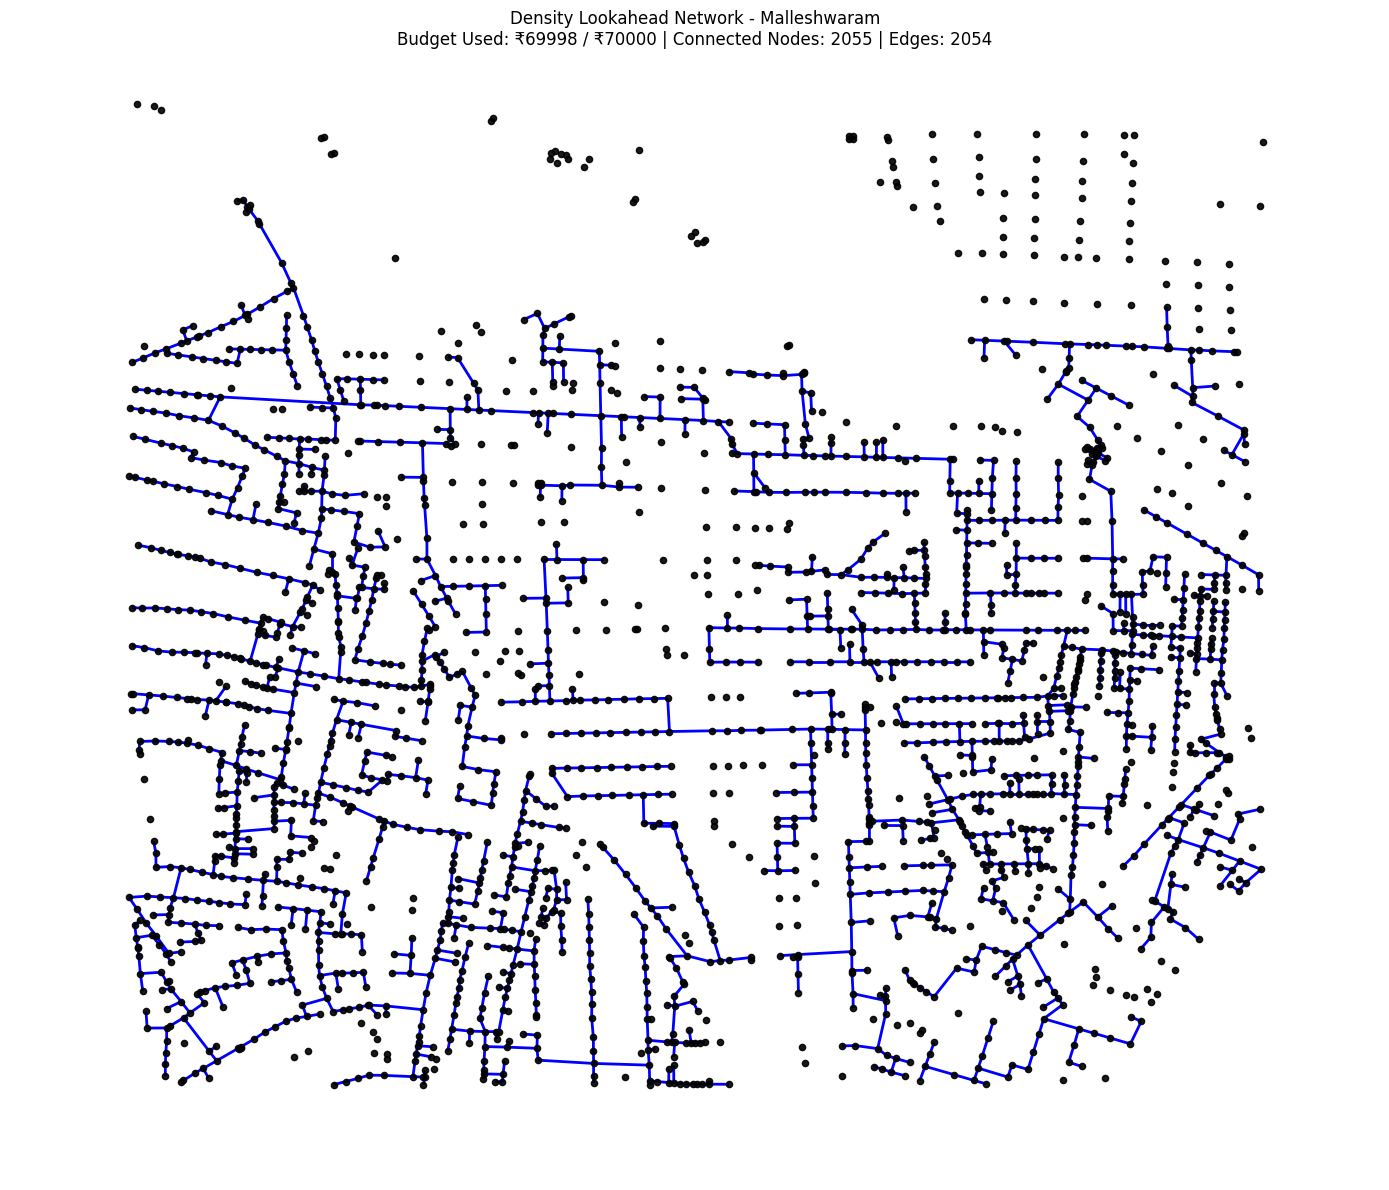

In [2]:
# ==========================================
# Density Lookahead Greedy - Malleshwaram
# + Clean Plot
# ==========================================

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load Malleshwaram Data
# -------------------------------
nodes_df = pd.read_csv("malleshwaram_nodes.csv")
edges_df = pd.read_csv("malleshwaram_edges.csv")

print(f"Loaded: {len(nodes_df)} nodes, {len(edges_df)} edges")

# -------------------------------
# 2. Build Graph (₹1 per meter)
# -------------------------------
G = nx.Graph()

# Add nodes with positions
for _, row in nodes_df.iterrows():
    G.add_node(int(row['node_id']),
               x=row['longitude'],
               y=row['latitude'])

# Add edges
for _, row in edges_df.iterrows():
    G.add_edge(int(row['source']),
               int(row['target']),
               length=float(row['distance_meters']))  # weight

print(f"Graph ready: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# -------------------------------
# 3. Heuristic Function
# -------------------------------
def density_lookahead_greedy(G, root_node, max_budget, weight_attr='length'):
    
    connected_nodes = {root_node}
    built_edges = set()
    spent_budget = 0.0
    
    while True:
        try:
            distances, paths = nx.multi_source_dijkstra(
                G, sources=connected_nodes, weight=weight_attr
            )
        except nx.NetworkXNoPath:
            break
            
        best_score = -1
        best_path = None
        best_path_cost = 0
        
        for target, path in paths.items():
            if target in connected_nodes:
                continue
                
            path_cost = distances[target]
            
            if spent_budget + path_cost > max_budget:
                continue
                
            num_new_nodes = len(path) - 1
            
            score = num_new_nodes / path_cost if path_cost > 0 else float('inf')
            
            if score > best_score:
                best_score = score
                best_path = path
                best_path_cost = path_cost
                
        if best_path is None:
            break
            
        for i in range(len(best_path) - 1):
            u = best_path[i]
            v = best_path[i+1]
            
            edge = tuple(sorted((u, v)))
            built_edges.add(edge)
            connected_nodes.add(v)
            
        spent_budget += best_path_cost
        
    return built_edges, connected_nodes, spent_budget


# -------------------------------
# 4. Run Heuristic
# -------------------------------
root = list(G.nodes())[0]   # choose any starting node
B = 700_00                 # budget (₹1 per meter)

print("Running heuristic...")
built_edges, connected_nodes, spent = density_lookahead_greedy(G, root, B)

print(f"Budget Used: {spent:.2f} / {B}")
print(f"Connected Nodes: {len(connected_nodes)}")
print(f"Edges Built: {len(built_edges)}")

# -------------------------------
# 5. Plot (Clean)
# -------------------------------
print("Plotting...")

# Create subgraph
H = nx.Graph()
H.add_nodes_from(G.nodes())
H.add_edges_from(built_edges)

# Positions
pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}

plt.figure(figsize=(14, 12))

# Black nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color='black',
    node_size=20,
    alpha=0.9
)

# Selected edges only
nx.draw_networkx_edges(
    H, pos,
    edge_color='blue',
    width=2.0
)

plt.title(
    f"Density Lookahead Network - Malleshwaram\n"
    f"Budget Used: ₹{spent:.0f} / ₹{B} | "
    f"Connected Nodes: {len(connected_nodes)} | "
    f"Edges: {len(built_edges)}"
)

plt.axis('off')
plt.tight_layout()

plt.savefig("malleshwaram_lookahead.png", dpi=300)
print("Saved: malleshwaram_lookahead.png")

plt.show()